In [6]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [7]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from pathlib import Path 
from IPython.display import display

In [8]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

d:\Documents\GitHub\-Time-Series-Analysis-and-Forecasting-methods-\data


# Time series decomposition

Time series data can exhibit a variety of patterns, and it is often helpful to split a time series into several components, each representing an underlying pattern category.

In this chapter, we discussed three types of time series patterns: trend, seasonality and cycles. When we decompose a time series into components, we usually combine the trend and cycle into a single trend-cycle component (often just called the trend for simplicity). Thus we can think of a time series as comprising three components: a trend-cycle component, a seasonal component, and a remainder component (containing anything else in the time series). For some time series (e.g., those that are observed at least daily), there can be more than one seasonal component, corresponding to the different seasonal periods.

In this chapter, we consider the most common methods for extracting these components from a time series. Often this is done to help improve understanding of the time series, but it can also be used to improve forecast accuracy.

When decomposing a time series, it is sometimes helpful to first transform or adjust the series in order to make the decomposition (and later analysis) as simple as possible. So we will begin by discussing transformations and adjustments.

## I. Transformations and adjustments

Here, we deal with four kinds of adjustments: calendar adjustments, population adjustments, inflation adjustments and mathematical transformations. The purpose of these adjustments and transformations is to simplify the patterns in the historical data by removing known sources of variation, or by making the pattern more consistent across the whole data set in order to be more accurate forecasts. 

### 1.1 Calendar adjustments

Some of the variation seen in seasonal data may be due to simple calendar effects. In such cases, it is usually much easier to remove the variation before doing any further analysis.

For example, if you are studying the total monthly sales in a retail store, there will be variation between the months simply because of the different numbers of trading days in each month, in addition to the seasonal variation across the year. It is easy to remove this variation by computing average sales per trading day in each month, rather than total sales in the month. Then we effectively remove the calendar variation.

### 1.2 Population adjustments

Any data that are affected by population changes can be adjusted to give per-capita data. That is, consider the data per person (or per thousand people, or per million people) rather than the total. For example, 

if you are studying the number of hospital beds in a particular region over time, the results are much easier to interpret if you remove the effects of population changes by considering the number of beds per thousand people. **Then you can see whether there have been real increases in the number of beds, or whether the increases are due entirely to population increases.** It is possible for the total number of beds to increase, but the number of beds per thousand people to decrease. This occurs when the population is increasing faster than the number of hospital beds. For most data that are affected by population changes, it is best to use per-capita data rather than the totals.

For exapmle, this can be seen in the global_economy dataset, where a common transformation of GDP is GDP per-capita.

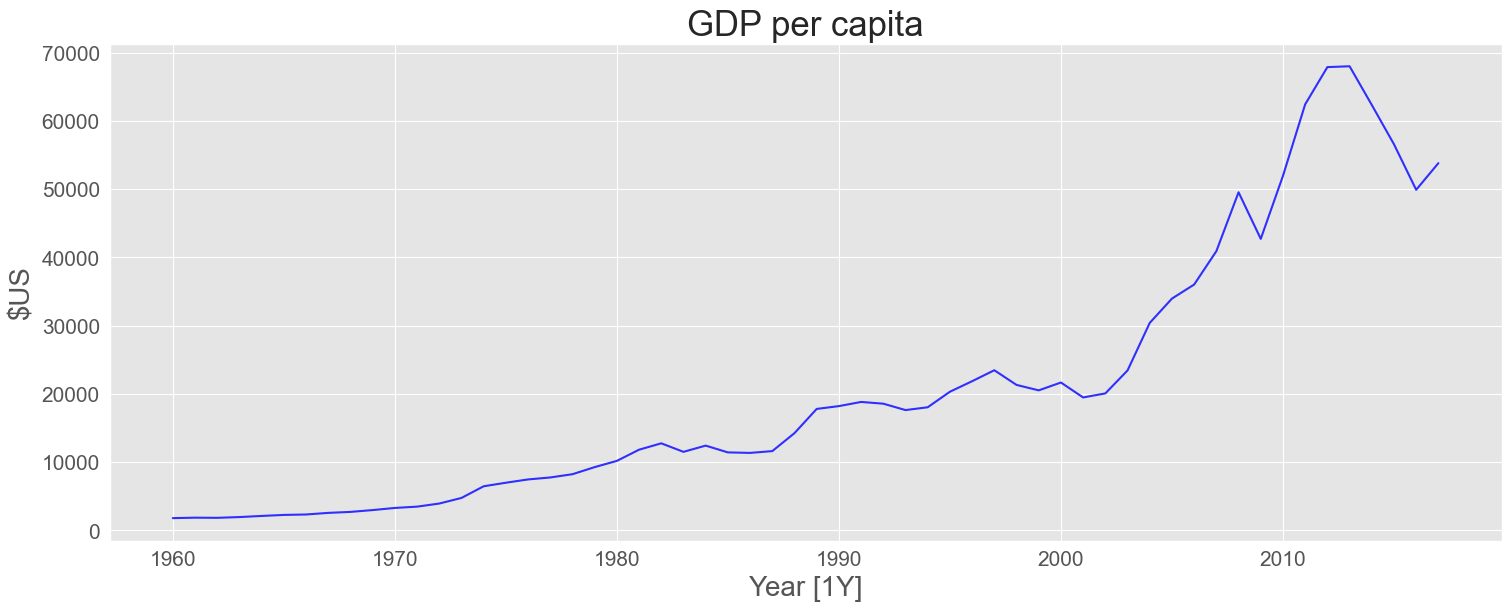

In [9]:
global_economy = pd.read_csv(DATA_DIR / "global_economy.csv")

df = (
    global_economy
    .loc[lambda x: x["unique_id"] == "Australia"]
    .assign(y=lambda x: x["GDP"] / x["Population"])
)
plot_series(df, xlabel="Year [1Y]", ylabel="$US", title="GDP per capita")

### 1.3 Inflation adjustments

Data which are affected by the value of money are best adjusted before modelling. For example, the average cost of a new house will have increased over the last few decades due to inflation. A $200,000 house this year is not the same as a $200,000 house twenty years ago. For this reason, financial time series are usually adjusted so that all values are stated in dollar values from a particular year. For example, the house price data may be stated in year 2000 dollars.

To make these adjustments, a price index is used. If $z_t$ denotes the price index and $y_t$ denotes the original house price in year $t$, then $x_t = \frac{y_t}{z_t} * z_{2000}$  gives the adjusted house price at year 2000 dollar values. Price indexes are often constructed by government agencies. For consumer goods, a common price index is the Consumer Price Index (or CPI).

This allows us to compare the growth or decline of industries relative to a common price value. For example,

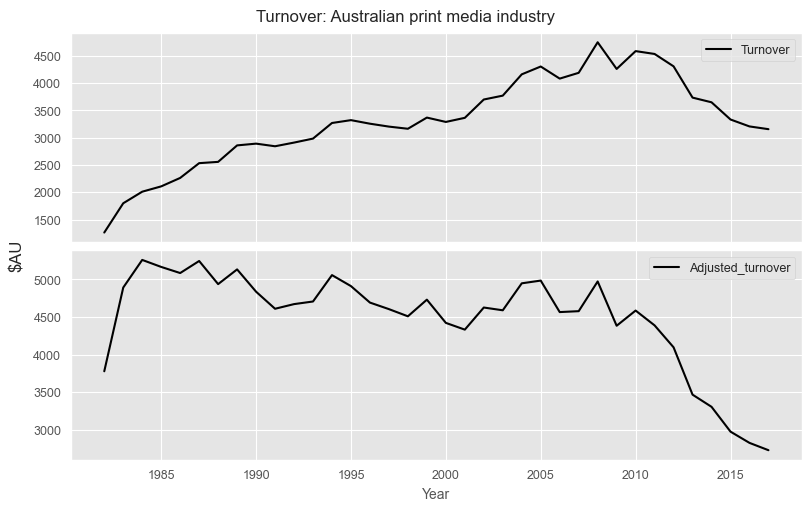

In [10]:
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates=["Month"])
print_retail = (
    aus_retail
    .loc[lambda x: x["Industry"] == "Newspaper and book retailing"]
    .assign(ds=lambda x: x["Month"].dt.year)
    .groupby("ds", as_index=False)
    ["Turnover"].sum()
)
aus_economy = global_economy.loc[lambda x: x["unique_id"] == "Australia"]
df = (
    aus_economy
    .merge(print_retail, on="ds", how="left")
    .assign(adjusted_turnover=lambda x: x["Turnover"] / x["CPI"] * 100)
    .dropna()
)
fig, axes = plt.subplots(2, 1, sharex=True)
sns.lineplot(data=df, x='ds', y='Turnover', ax=axes[0],
    color='black', label="Turnover")
sns.lineplot(data=df, x='ds', y='adjusted_turnover', ax=axes[1],
    color='black', label="Adjusted_turnover")
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel='Year')
fig.suptitle("Turnover: Australian print media industry")
fig.supylabel("$AU")
plt.show()

By adjusting for inflation using the CPI, we can see that Australia’s newspaper and book retailing industry has been in decline much longer than the original data suggests. The adjusted turnover is in 2010 Australian dollars, as CPI is 100 in 2010 in this data set.

### 1.4 Mathematical transformations

If the data shows variation that increases or decreases with the level of the series, then a transformation can be useful. 

For example, a logarithmic transformation is often useful. If we denote the original observations as $y_1, ..., y_T$ and and the transformed observations as $w_1, ..., w_T$, then $w_t = log(y_t)$. 

Logarithms are useful because they are interpretable: changes in a log value are relative (or percentage) changes on the original scale. So if log base 10 is used, then an increase of 1 on the log scale corresponds to a multiplication of 10 on the original scale. If any value of the original series is zero or negative, then logarithms are not possible.


Sometimes other transformations are also used (although they are not so interpretable). For example, square roots and cube roots can be used. These are called power transformations because they can be written in the form $w_t = y_{t}^p$

A useful family of transformations, that includes both logarithms and power transformations, is the family of Box-Cox transformations (Box & Cox, 1964), which depend on the parameter $λ$ and are defined as follows: 
$$w_t = \begin{cases} \log(y_t) & \text{if } \lambda = 0; \\ (\text{sign}(y_t)|y_t|^\lambda - 1)/\lambda & \text{otherwise.} \end{cases}$$

The logarithm in a Box-Cox transformation is always a natural logarithm (i.e., to base $e$). So if λ=0, natural logarithms are used, but if λ≠0, a power transformation is used, followed by some simple scaling.

**A good value of λ** is one which makes the size of the seasonal variation about the same across the whole series, as that makes the forecasting model simpler.


You can apply the Box-Cox transformation directly to the data using the boxcox() function from CoreForecast. To automatically determine a λ value for the Box-Cox transformation, use the boxcox_lambda() function from CoreForecast. This function requires the season_length of the series and uses the method by Guerrero (1993) to choose a value for λ. In this example, it chooses λ=0.11.

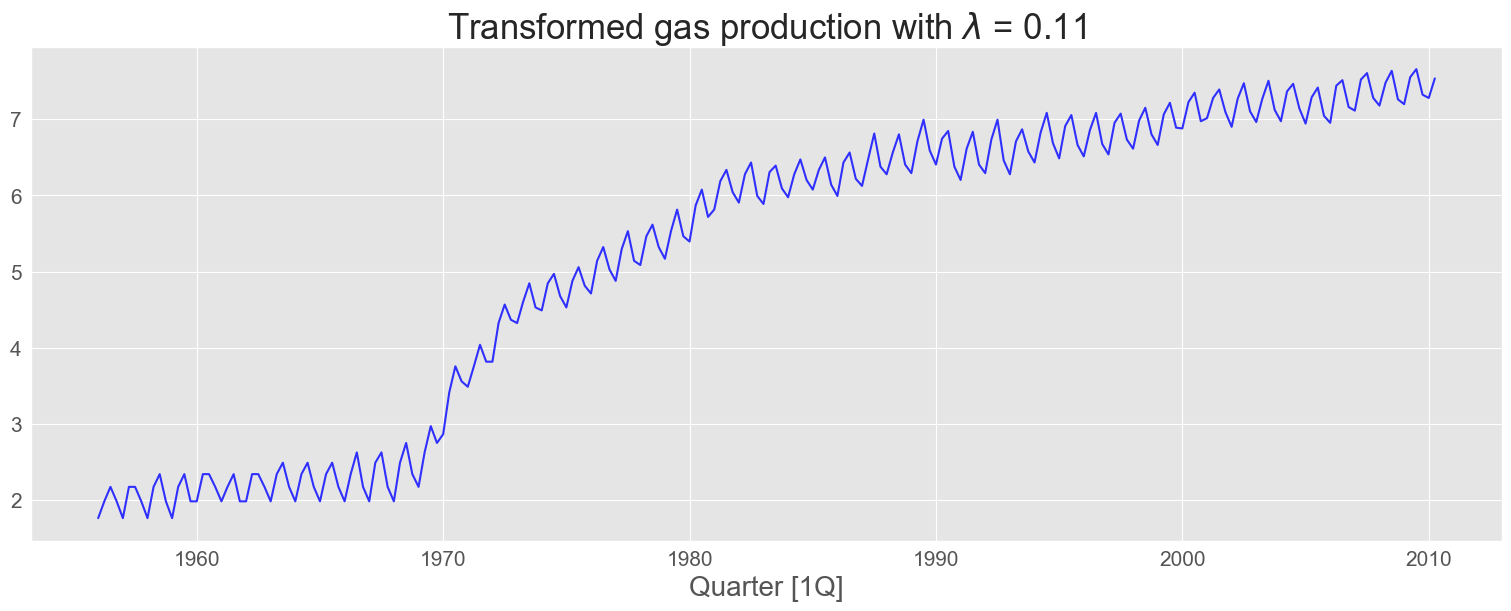

In [11]:
aus_production = pd.read_csv(DATA_DIR / "aus_production.csv",
    parse_dates=["ds"])
aus_gas = (
    aus_production[["ds", "Gas"]]
    .rename(columns={"Gas": "y"}).assign(unique_id="Gas")
)
y = aus_gas["y"].to_numpy()
optim_lambda = boxcox_lambda(y, method="guerrero", season_length=4)

df = aus_gas.assign(y_transformed=boxcox(y, optim_lambda))
title = rf"Transformed gas production with $\lambda$ = {optim_lambda:.2f}"
plot_series(df, target_col="y_transformed",
    xlabel="Quarter [1Q]", ylabel="", title=title)

## II. Time Series componenents

Bất kỳ đường cong doanh số nào của một sản phẩm cũng được cấu thành từ 3 yếu tố toán học. Bạn cần "rã" (decompose) dữ liệu lịch sử thành 3 phần này: 
- **Trend (Xu hướng):** Hướng đi chung của sản phẩm (đang hot lên dần hay đang lỗi thời dần).
- **Seasonality (Tính mùa vụ):** Các đợt tăng/giảm lặp đi lặp lại theo chu kỳ cố định (ví dụ: áo khoác luôn bán chạy vào tháng 11-12, đồ bơi bán chạy vào tháng 5).
- **Residual/Noise (Nhiễu):** Những biến động ngẫu nhiên không giải thích được (ví dụ: trời mưa đột xuất, bão, hoặc do một post viral ngẫu nhiên).

**Công thức gốc:** $$
y_{t} = S_{t} \times T_{t} \times R_t$$(Mô hình nhân - Multiplicative Model thường dùng cho bán lẻ vì biên độ mùa vụ tăng theo quy mô)

Phân tích cộng là phương pháp phù hợp nhất nếu biên độ của các biến động theo mùa, hoặc sự biến đổi xung quanh chu kỳ xu hướng, không thay đổi theo cấp độ của chuỗi thời gian. Khi sự biến đổi trong mô hình theo mùa, hoặc sự biến đổi xung quanh chu kỳ xu hướng, có vẻ tỷ lệ thuận với cấp độ của chuỗi thời gian, thì phân tích nhân sẽ phù hợp hơn. Phân tích nhân thường được sử dụng với các **chuỗi thời gian kinh tế**.

An alternative to using a multiplicative decomposition is to first transform the data until the variation in the series appears to be stable over time, then use an additive decomposition. When a log transformation has been used, this is equivalent to using a multiplicative decomposition because $$y_{t} = S_{t} \times T_{t} \times R_t \quad\text{is equivalent to}\quad
  \log y_{t} = \log S_{t} + \log T_{t} + \log R_t.$$

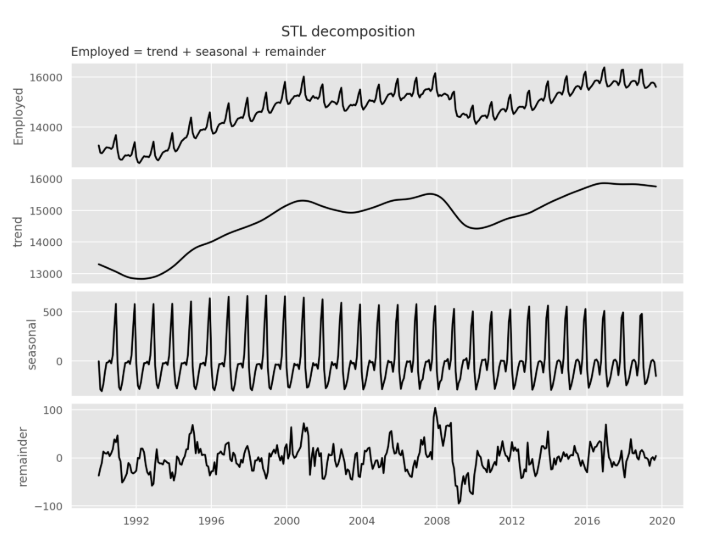

The three components are shown separately in the bottom three panels. These components can be added together to reconstruct the data shown in the top panel. Notice that the seasonal component changes over time, so that any two consecutive years have similar patterns, but years far apart may have different seasonal patterns. The remainder component shown in the bottom panel is what is left over when the seasonal and trend-cycle components have been subtracted from the data.

### Seasonally adjusted data

If the seasonal component is removed from the original data, the resulting values are the “seasonally adjusted” data. 

If the variation due to seasonality is not of primary interest, the seasonally adjusted series can be useful. For example, monthly unemployment data are usually seasonally adjusted in order to highlight variation due to the underlying state of the economy rather than the seasonal variation. An increase in unemployment due to school leavers seeking work is seasonal variation, while an increase in unemployment due to an economic recession is non-seasonal. Most economic analysts who study unemployment data are more interested in the non-seasonal variation. Consequently, employment data (and many other economic series) are usually seasonally adjusted.

Seasonally adjusted series contain the remainder component as well as the trend-cycle. Therefore, they are not “smooth”, and “downturns” or “upturns” can be misleading. If the purpose is to look for turning points in a series, and interpret any changes in direction, then it is better to use the trend-cycle component rather than the seasonally adjusted data.


## III. Moving averages 


Moving averages are the first step in classical time series decomposition, primarily used to estimate the **trend-cycle** component by smoothing out randomness and seasonal variations.

#### 1. Moving Average Smoothing
A moving average of order $m$ (denoted as $m$-MA) estimates the trend-cycle by averaging the values of the time series within $k$ periods of time $t$. A larger order $m$ results in a smoother curve, and odd numbers are typically used so the average remains perfectly symmetric.

**Formula:**
$$ \hat{T}_{t} = \frac{1}{m} \sum_{j=-k}^k y_{t+j} $$
*(Where $m = 2k+1$, meaning the moving average is perfectly centered around observation $t$)*.

#### 2. Moving Averages of Moving Averages
Applying a moving average to the results of another moving average is usually done to **make an even-order moving average symmetric**. For instance, a 4-MA followed by a 2-MA (called a $2 \times 4$-MA or "centred moving average of order 4") effectively weights the observations so that the final average is symmetrically centered. 

**Formula (Example for a $2 \times 4$-MA):**
$$ \hat{T}_{t} = \frac{1}{2}\Big[ \frac{1}{4} (y_{t-2}+y_{t-1}+y_{t}+y_{t+1}) + \frac{1}{4} (y_{t-1}+y_{t}+y_{t+1}+y_{t+2})\Big] $$
Which simplifies to:
$$ \hat{T}_{t} = \frac{1}{8}y_{t-2}+\frac{1}{4}y_{t-1} + \frac{1}{4}y_{t}+\frac{1}{4}y_{t+1}+\frac{1}{8}y_{t+2} $$

#### 3. Estimating the Trend-Cycle with Seasonal Data
To ensure seasonal variation is properly smoothed out, the order of the moving average must align with the seasonal period. For an even seasonal period $m$ (like monthly data where $m=12$), a **$2 \times m$-MA** is used. For an odd seasonal period (like a 7-day week), a simple **$m$-MA** is used. Using incorrect orders will leave the trend-cycle contaminated by seasonality.

**Formula Structure (For an even period using a $2 \times m$-MA):**
A $2 \times m$-MA is equivalent to a weighted moving average of order $m+1$, where all middle observations take the weight $1/m$, and the first and last terms take the weight:
$$ \text{End Weights} = \frac{1}{2m} $$

#### 4. Weighted Moving Averages
Any combination of moving averages results in a weighted moving average. A major advantage of using weighted moving averages is that they produce a **smoother estimate of the trend-cycle** because the weights of the observations slowly increase and decrease rather than sharply entering and leaving the calculation. The simple $m$-MA is just a special case where all weights equal $1/m$.

**Formula:**
$$ \hat{T}_t = \sum_{j=-k}^k a_j y_{t+j} $$
*(Where $k = (m-1)/2$, the weights are $[a_{-k}, \dots, a_k]$, all weights sum to one, and they are symmetric so that $a_j = a_{-j}$)*.

## IV. Classical Decomposition

Originating in the 1920s, classical decomposition is a relatively simple procedure that forms the starting point for most time series decomposition methods. A key assumption of this method is that the seasonal component remains completely constant from year to year. 

For a time series with a seasonal period of $m$ (e.g., $m=12$ for monthly data), classical decomposition is performed in four steps, using either an additive or a multiplicative model in order to ensure symmetry.

### 1. Additive Decomposition
Additive decomposition is used when the magnitude of seasonal fluctuations is roughly constant over time. 

*   **Step 1: Estimate the Trend-Cycle** 
    Compute the trend-cycle component ($\hat{T}_t$). If the seasonal period $m$ is an even number, use a $2 \times m$-MA. If $m$ is an odd number, use an $m$-MA.
*   **Step 2: Calculate the Detrended Series**
    Subtract the trend-cycle estimate from the original data.
    **Formula:** 
    $$ \text{Detrended Series} = y_t - \hat{T}_t $$
*   **Step 3: Estimate the Seasonal Component ($\hat{S}_t$)**
    Average the detrended values for each specific season (e.g., the average of all detrended March values). These seasonal values are then adjusted to ensure that they add up to exactly zero. The sequence is replicated for each year to form the full seasonal component, $\hat{S}_t$.
*   **Step 4: Calculate the Remainder Component ($\hat{R}_t$)**
    Subtract the estimated trend-cycle and seasonal components from the original time series data.
    **Formula:** 
    $$ \hat{R}_t = y_t - \hat{T}_t - \hat{S}_t $$

### 2. Multiplicative Decomposition
Multiplicative decomposition is used when seasonal variations change proportionally with the level of the time series. The subtractions in the additive method are replaced by divisions. The seasonal values in this method are often referred to as "seasonal indices".

*   **Step 1: Estimate the Trend-Cycle**
    Exactly the same as the additive method: compute $\hat{T}_t$ using a $2 \times m$-MA (if $m$ is even) or an $m$-MA (if $m$ is odd).
*   **Step 2: Calculate the Detrended Series**
    Divide the original data by the trend-cycle estimate.
    **Formula:**
    $$ \text{Detrended Series} = \frac{y_t}{\hat{T}_t} $$
*   **Step 3: Estimate the Seasonal Component ($\hat{S}_t$)**
    Average the detrended values for each specific season. These seasonal indices are then adjusted to ensure that they add up to exactly $m$. The sequence is replicated for each year of data to form $\hat{S}_t$.
*   **Step 4: Calculate the Remainder Component ($\hat{R}_t$)**
    Divide the original time series by the product of the estimated trend-cycle and seasonal components.
    **Formula:**
    $$ \hat{R}_t = \frac{y_t}{\hat{T}_t \hat{S}_t} $$

### 3. Limitations of Classical Decomposition
While historically important, classical decomposition is generally no longer recommended because of several major drawbacks:
*   **Missing Endpoint Estimates:** Because it relies on moving averages, trend-cycle and remainder estimates are unavailable for the first few and last few observations (e.g., the first and last six months are missing for monthly data).
*   **Over-smoothing:** The trend-cycle estimate tends to over-smooth rapid rises and falls in the data.
*   **Static Seasonality:** It assumes the seasonal pattern strictly repeats every year, rendering it incapable of capturing changes over time (such as changing energy consumption patterns).
*   **Vulnerability to Outliers:** The method is not robust to unusual values, such as strikes or temporary industrial disputes.

## 3.5 Methods used by official statistics agencies

Official statistics agencies, such as the US Census Bureau and the Australian Bureau of Statistics, frequently deal with a vast amount of economic and social time series data. To handle seasonal adjustments for these series, they have developed their own advanced decomposition procedures, primarily relying on the **X-11 method**, the **SEATS method**, or a combination of the two. 

A significant limitation of these official methods is that they are designed **specifically for quarterly and monthly data**, which are the most common reporting formats for government agencies. They cannot handle other types of seasonality, such as daily, weekly, or hourly patterns.

### 1. The X-11 Method
Originating from the US Census Bureau and further developed by Statistics Canada, the X-11 method builds upon the foundation of classical decomposition but adds numerous extra steps to overcome its historical drawbacks. 

**Key improvements over classical decomposition include:**
*   **Complete Estimates:** It successfully provides trend-cycle estimates for *all* observations, including the missing endpoints that classical methods fail to calculate.
*   **Dynamic Seasonality:** The seasonal component is allowed to vary slowly over time, rather than remaining strictly static.
*   **Advanced Adjustments:** It automatically handles trading day variations, holiday effects, and the effects of known predictors.
*   **Robustness:** The process is entirely automatic and highly resistant to anomalies like outliers and level shifts.

The X-11 method supports both additive and multiplicative decomposition models.

### 2. The SEATS Method
SEATS stands for **"Seasonal Extraction in ARIMA Time Series"**. Originally developed at the Bank of Spain, it has become widely adopted by government agencies worldwide. While the text notes that the mathematical procedures for SEATS are beyond the scope of the book, it operates closely with ARIMA models (discussed later in the text) to extract seasonal components.

## 3.6 STL Decomposition

**STL** stands for **"Seasonal and Trend decomposition using Loess"**, where *loess* is a mathematical method for estimating nonlinear relationships. Developed initially in 1990 and later extended to handle multiple seasonal patterns, STL is a highly versatile and robust method for decomposing time series.

### 1. Advantages of STL
STL offers several major advantages over classical decomposition and official methods like X-11 and SEATS:
*   **Universal Seasonality:** It can handle *any* type of seasonality (including daily, weekly, or hourly data), not just monthly or quarterly series.
*   **Dynamic Components:** The seasonal component is allowed to change over time, and the user can explicitly control the rate of this change.
*   **Controllable Smoothness:** The user has direct control over how smooth the trend-cycle estimate should be.
*   **Robustness to Outliers:** STL can be set to a "robust" mode, ensuring that occasional unusual observations (outliers) do not distort the trend-cycle or seasonal estimates; instead, these anomalies are pushed strictly into the remainder component.

### 2. Disadvantages of STL
Despite its versatility, STL has two primary drawbacks:
*   It does not automatically handle calendar variation or trading day effects.
*   It is inherently designed **only for additive decompositions**.

### 3. Handling Multiplicative Data in STL (Formulas)
Because STL only performs additive decomposition, you must use mathematical transformations if your data exhibits multiplicative seasonality (where seasonal variation scales with the level of the series). 

**Method A: Logarithmic Transformation**
You can achieve a multiplicative decomposition by first taking the natural log of the original data, running the additive STL decomposition, and then back-transforming the components.
**Formula:**
$$ \log y_{t} = \log S_{t} + \log T_{t} + \log R_t $$
*(This is mathematically equivalent to the multiplicative model $y_t = S_t \times T_t \times R_t$)*.

**Method B: Box-Cox Transformation**
You can also apply a Box-Cox transformation to the data before using STL, which allows for decompositions that sit anywhere between additive and multiplicative. 
**Formula:**
$$ w_t = \begin{cases} \log(y_t) & \text{if } \lambda=0; \\ (\text{sign}(y_t)|y_t|^\lambda-1)/\lambda & \text{otherwise}. \end{cases} $$
*   Setting **$\lambda = 1$** yields an additive decomposition.
*   Setting **$\lambda = 0$** yields a completely multiplicative decomposition.
*   Values between $0 < \lambda < 1$ provide a blend of the two.

### 4. Key Parameters in STL
When using STL (such as via the `STL()` function in Python's `statsmodels`), the two most important parameters to configure are:
*   **`trend`**: The length of the trend smoother.
*   **`season`**: The length of the seasonal smoother.

Both parameters control how rapidly their respective components are allowed to change (smaller values allow for more rapid, flexible changes, while larger values create rigid, smoother curves). **Both the trend and seasonal windows must always be odd numbers**. While default automated settings often work well, they sometimes need manual adjustment—for example, if a default trend window is too rigid, it might inadvertently leak major economic shifts (like a financial crisis) into the remainder component rather than capturing it in the trend.

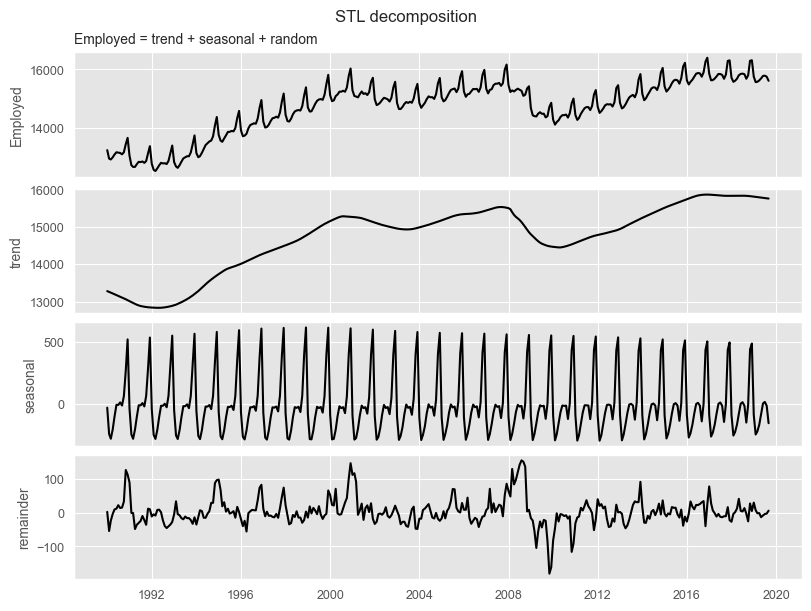

In [15]:
us_employment = pd.read_csv(DATA_DIR / "us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
]
stl = STL(us_retail_employment["y"], period=12,
    seasonal=13, trend=21, robust=True)
res_stl = stl.fit()
dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + random",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()